# Triangle Plots

This is the notebook used to create the triangle plots for various situations of lockdown start day, number of lockdowns, etc found in Figure 5 of my report.

`outbreakFunctions.py` contains the classes needed to simulate the model, and `costFunctions.py` contains the functions required to calculate cost, optimal strategy, and actually create the triangle plots.

If you want to print the net monetary loss values, an index of `12` gives (0.1,0.1,0.8), `19` gives (0.1,0.8,0.1), `33` gives (0.3,0.3,0.4), and `61` gives (0.8,0.1,0.1). So for example:

`print("Loss when schools closed for weighting", w1closed[12], w2closed[12], w3closed[12], "is £", lossClosed[12])`

Will print:

Loss when schools closed for weighting 0.1, 0.1, 0.8 is £X

where X is the net monetary loss.

Those four indices are what were used to get the values found in Appendix D, figure 7.

### Table of Contents

- [**One variant**](#onevar)  
  > •[One lockdown](#oneLDvar1)   
  > •[Two lockdowns, start on day 108](#twoLD_day108var1)  
  > •[Two lockdowns, start on day 200](#twoLD_day200var1)  
  
- [**Two variants**](#twovars)  
  > •[One lockdown](#oneLDvar2)   
  > •[Two lockdowns, start on day 108](#twoLD_day108var2)  
  > •[Two lockdowns, start on day 200](#twoLD_day200var2)   

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace
import math
import mpltern
import matplotlib.colors as mcolors
import time

import outbreakFunctions
import costFunctions

f = open("params.json", "r")
contents = f.read()
f.close()


params = json.loads(contents)

    
youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

allAgeGrpParams = (youngAgeGrp, adultAgeGrp, elderlyAgeGrp)

# Optimal Strategies for **one variant** <a id = 'onevar' ><a>

In [2]:
days = 365
efficaciesArray = [0.5, 0.7, 0.9]
vaccineStart = 70
n = 10
outbreak2Start = days + 1
weekStart, weekEnd, weekIncrement = 0, 30, 2 
wks = np.arange(weekStart, weekEnd, weekIncrement)

## One Lockdown <a id = 'oneLDvar1' ><a>

### Willingness to pay £20,000

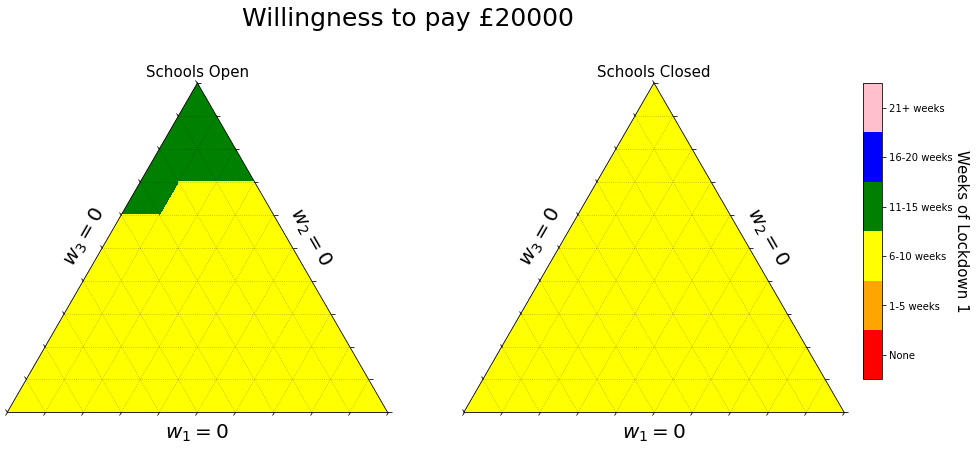

In [4]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

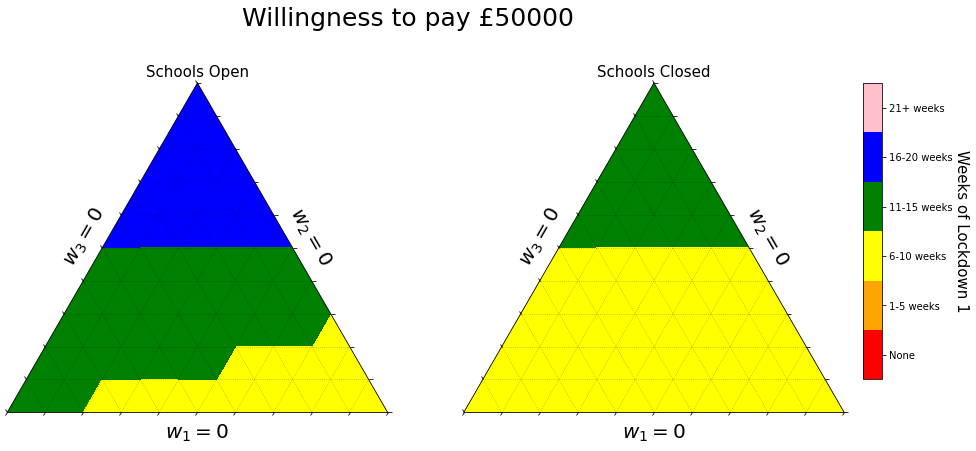

In [5]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

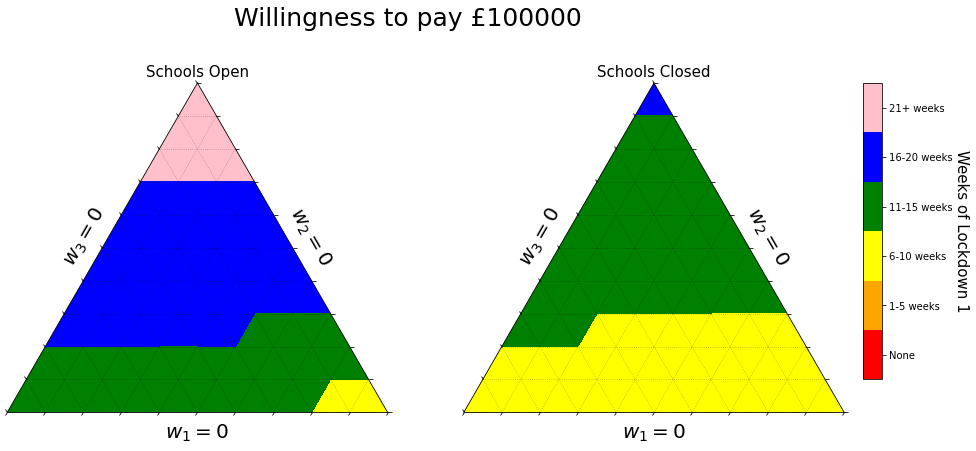

In [6]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

## 2 Lockdowns, start day 108 <a id = 'twoLD_day108var1' ><a>

### Willingness to pay £20,000

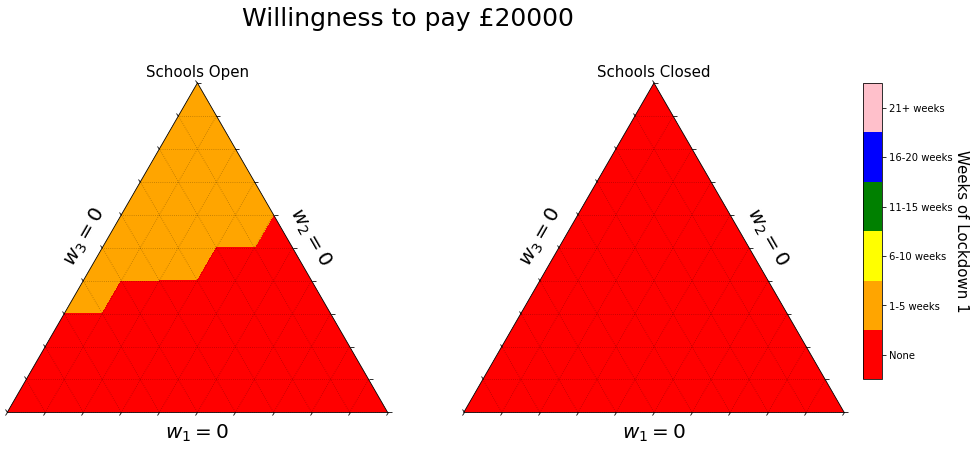

In [7]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

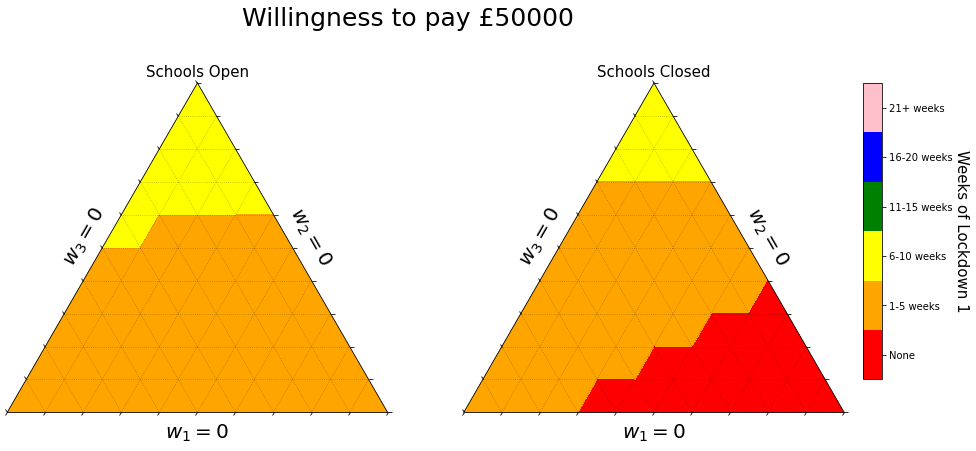

In [8]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

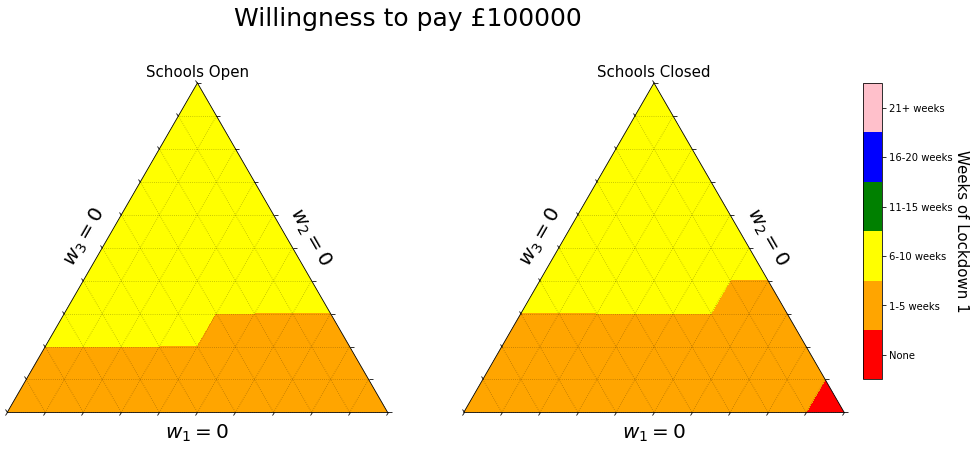

In [9]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

## 2 Lockdowns, start day 200 <a id = 'twoLD_day200var1' ><a>

### Willingness to pay £20,000

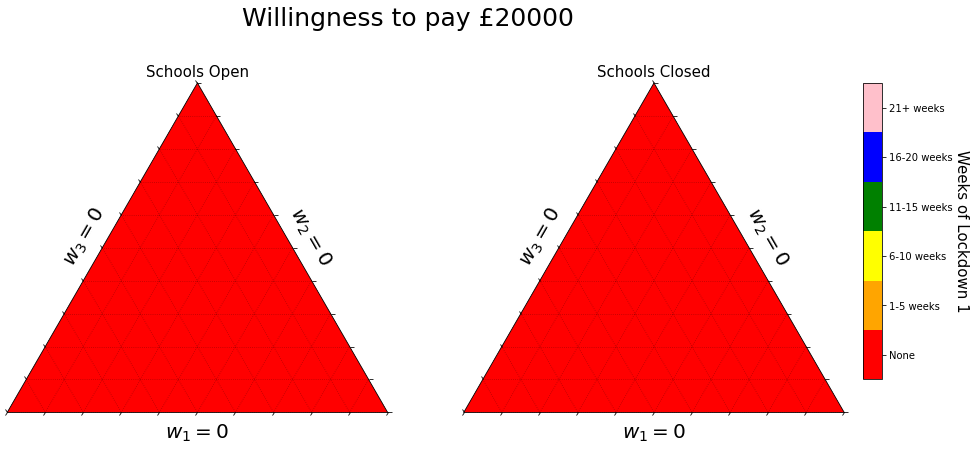

In [10]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

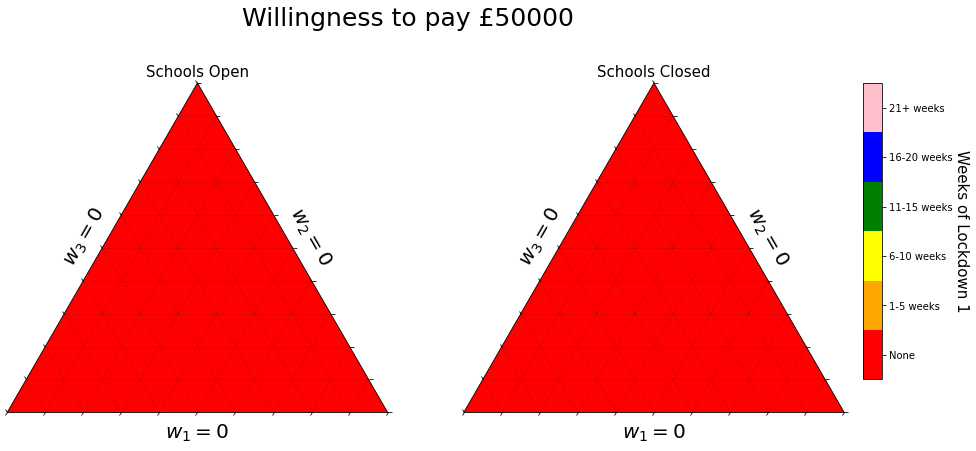

In [11]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

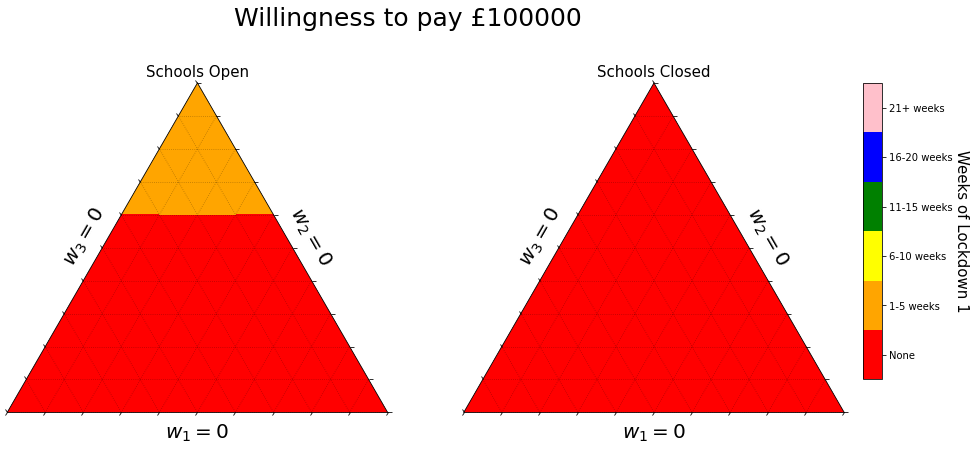

In [12]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

# Optimal Strategies for **two variants** <a id = 'twovars' ><a>

*Start day* here refers to the start of lockdown 1, and the optimal lockdown length is of lockdown 1. Lockdown 2 is currently fixed at 4 weeks long, beginning 40 days after lockdown 1 ends.

In [13]:
days = 365
efficaciesArray = [0.5, 0.7, 0.9]
vaccineStart = 70
n = 10
outbreak2Start = 150
weekStart, weekEnd, weekIncrement = 0, 30, 2 
wks = np.arange(weekStart, weekEnd, weekIncrement)

## One lockdown <a id = 'oneLDvar2' ><a>

### Willingness to pay £20,000

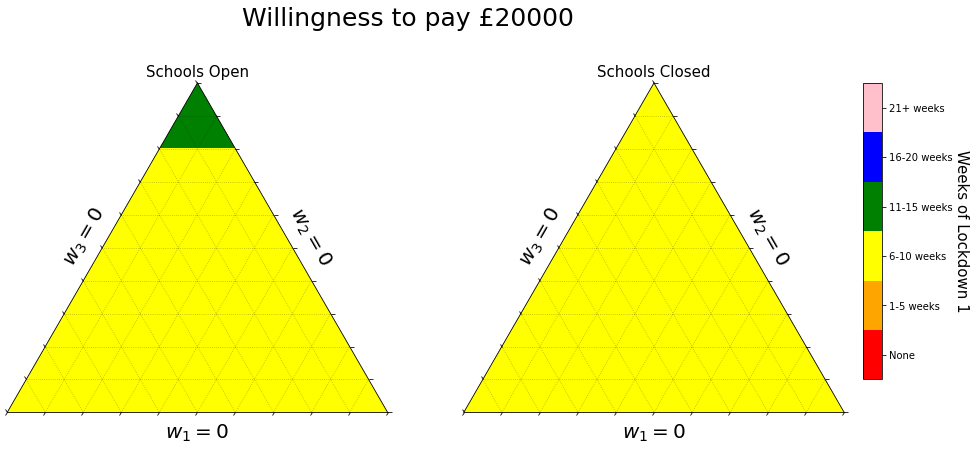

In [14]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

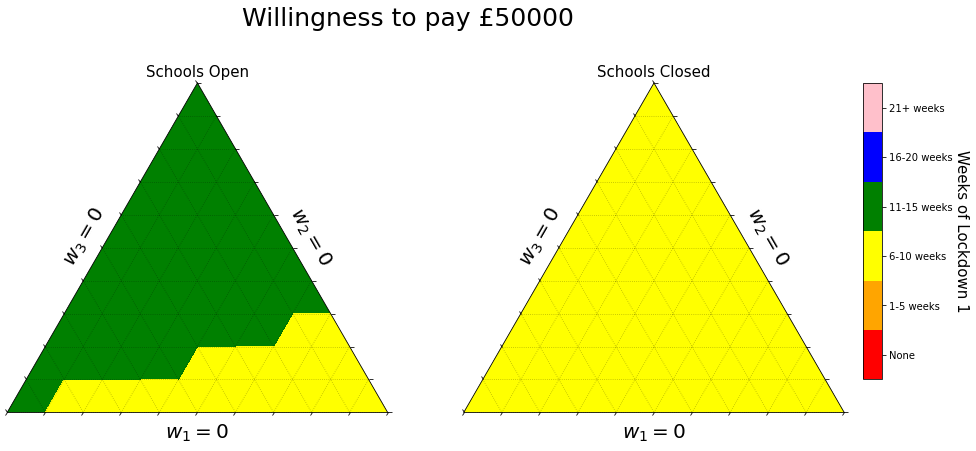

In [15]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

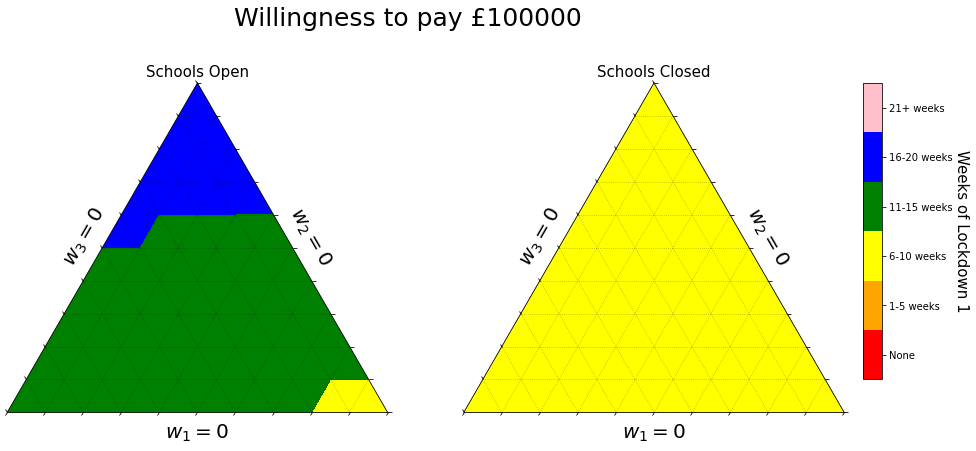

In [16]:
lockdown1Start = 40
lockdown2Start = days+1
whichLockdownVaried = 1
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

## 2 Lockdowns, start day 108 <a id = 'twoLD_day108var2' ><a>

### Willingness to pay £20,000

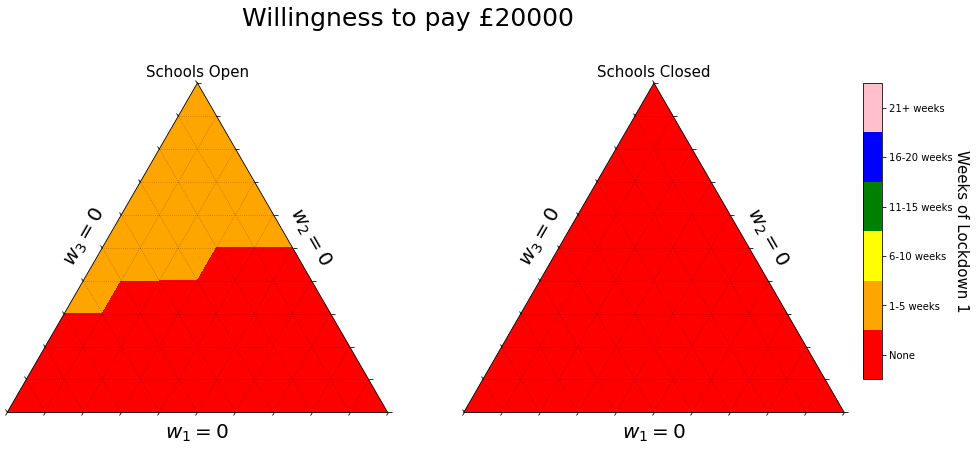

In [17]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

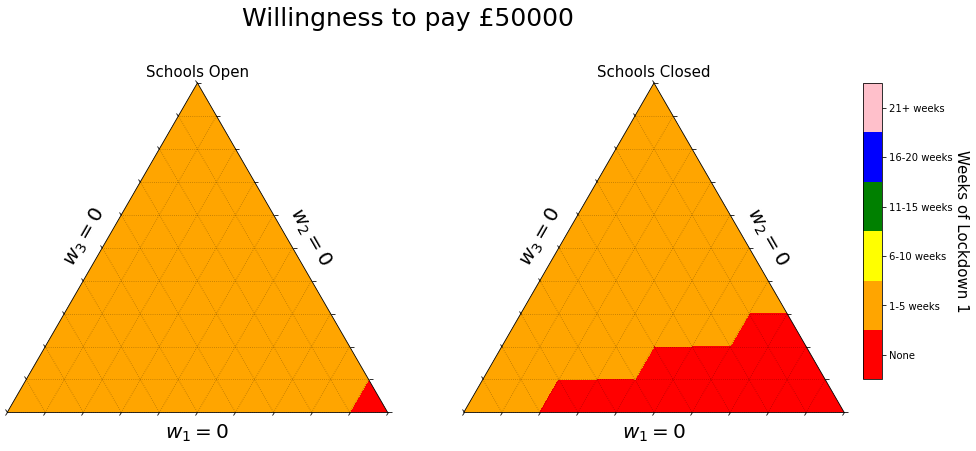

In [18]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

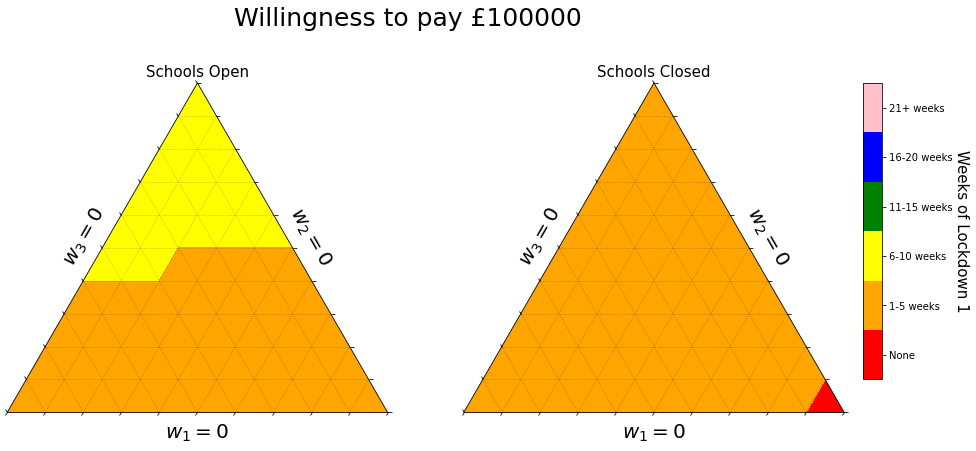

In [19]:
lockdown1Start = 40
lockdown2Start = 108
whichLockdownVaried = 2
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

## 2 Lockdowns, start day 200 <a id = 'twoLD_day200var2' ><a>

### Willingness to pay £20,000

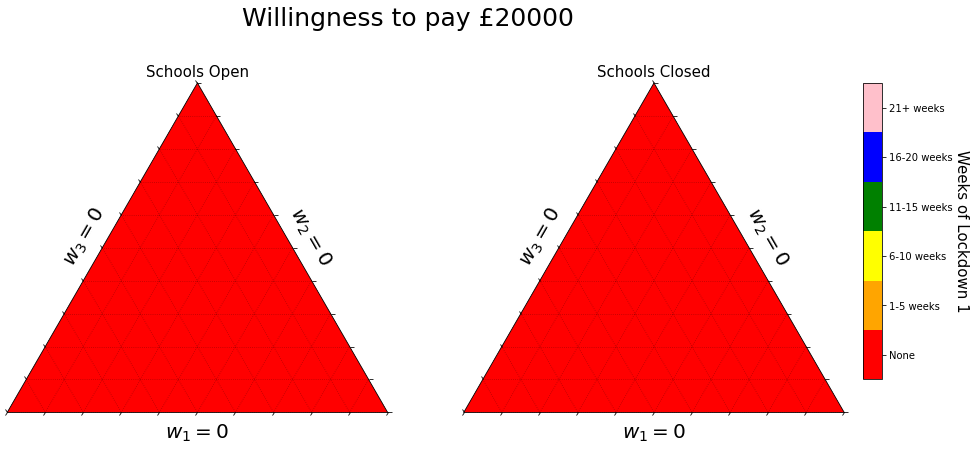

In [20]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 20000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £50,000

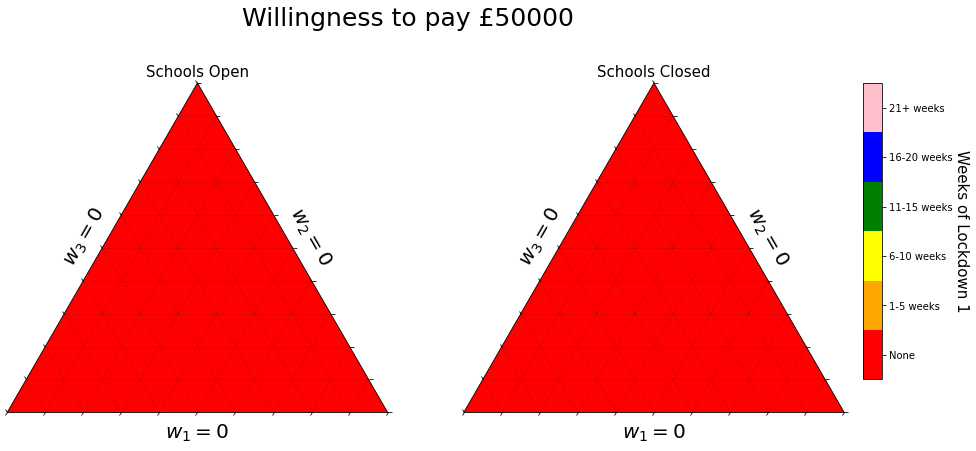

In [21]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 50000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)

### Willingness to pay £100,000

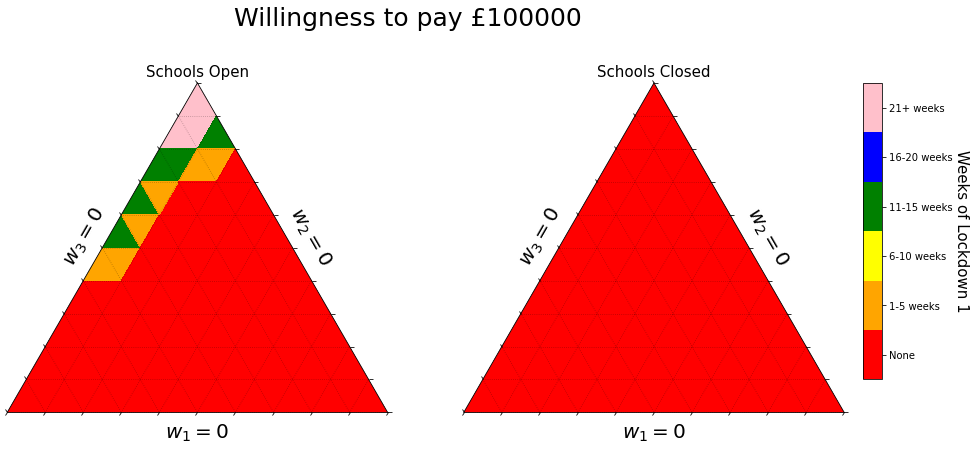

In [22]:
lockdown1Start = 40
lockdown2Start = 200
whichLockdownVaried = 2
W = 100000

schoolClosure = True  # Schools Closed
w1closed,w2closed,w3closed,resultsClosed, lossClosed = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w1open,w2open,w3open,resultsOpen, lossOpen = costFunctions.optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2Start, whichLockdownVaried, W, wks, n, outbreak2Start, days, schoolClosure)

# Plotting:
schoolsClosedArray = w1closed, w2closed, w3closed, resultsClosed
schoolsOpenArray = w1open, w2open, w3open, resultsOpen

costFunctions.trianglePlotterSchoolsOpenVsClosed(W, schoolsOpenArray, schoolsClosedArray)